# Differece calculations between frames

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import cv2

## Load in the data

In [ ]:
def get_data(dataset,X,num=-1,augment=False,sobel=True,printer="resin",filament="resin",pressure="P30",pattern="",augtests=[]):
    subset = dataset[((dataset['Printer'] == printer) & (dataset['Filament']==filament)) ]
    if pattern!="":
        subset = subset[subset['Pattern'].str.contains(pattern, regex=False, na=False) ]
    subX, y = [], []
    for _, row in subset.iterrows():
        images=X[int(row['Index'])]
        images=images.reshape((2*25,images.shape[2],images.shape[3]))
        try:
            label=int(row['Pattern'].split(".")[0].replace("z", ""))
        except:
            label=""
        if label!="":
            for image in images:
                if sobel:
                    # Apply Sobel filter (on grayscale if not already)
                    if len(image.shape) == 3:  # convert to grayscale if it's RGB
                        roi_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    else:
                        roi_gray = image

                    sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
                    sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)

                    sobel_ = np.hypot(sobelx, sobely)  # magnitude
                    image = cv2.convertScaleAbs(sobel_)  # scale back to uint8
                if num==-1:
                    y.append(label)
                    subX.append(image)
                else: 
                    try:
                        counter=int(row['Pattern'].split(".")[1])
                        if counter==num:
                            y.append(label)
                            subX.append(image)
                    except:
                        pass
    subX,y=np.array(subX),np.array(y)
    if augment:
        if len(augtests)==0 or 0 in augtests:
            noisy=subX+np.random.normal(0,5,subX.shape)
            subX=np.concatenate([subX,noisy])
            y=np.concatenate([y,y])
        if len(augtests)==1 or 1 in augtests:
            light=subX.copy()-10
            dark=subX.copy()+10
            light[light<0]=0
            dark[dark>255]=255
            subX=np.concatenate([subX,light,dark])
            y=np.concatenate([y,y,y])
    assert len(subX)==len(y) 
    return subX.reshape((len(subX)//(2*25),2,25,subX.shape[1],subX.shape[2])),y #shape into correct format

def coral_align_target_to_source(Xs, Xt, eps=1e-6):
    # center
    mu_s = Xs.mean(axis=0, keepdims=True)
    mu_t = Xt.mean(axis=0, keepdims=True)
    Xs_c = Xs - mu_s
    Xt_c = Xt - mu_t

    # covariances with small ridge
    cov_s = np.cov(Xs_c, rowvar=False) + np.eye(Xs_c.shape[1]) * eps
    cov_t = np.cov(Xt_c, rowvar=False) + np.eye(Xt_c.shape[1]) * eps

    # matrix square-roots via SVD
    Us, Ss, _ = np.linalg.svd(cov_s)
    Ut, St, _ = np.linalg.svd(cov_t)
    # cov_s^{1/2} and cov_t^{-1/2}
    cov_s_sqrt = Us @ np.diag(np.sqrt(Ss)) @ Us.T
    cov_t_inv_sqrt = Ut @ np.diag(1.0/np.sqrt(St)) @ Ut.T

    # transform target: Xt_aligned = (Xt_c @ cov_t^{-1/2}) @ cov_s^{1/2} + mu_s
    Xt_aligned = (Xt_c @ cov_t_inv_sqrt) @ cov_s_sqrt + mu_s
    return Xt_aligned

X=np.load("/home/dexter/Documents/GitHub/3D-textures/Experimental/data/X.npy")
dataset=pd.read_csv("/home/dexter/Documents/GitHub/3D-textures/Experimental/datameta.csv")
print("Original X shape:", X.shape)
print("Original dataset size:", len(dataset))
printers=[["resin","resin"],["ender","PLAplus"],["bambu","PLAminus"],]

image_brightness = X.mean(axis=(3, 4))
# shape: N x 2 x 25

# Overall distribution of image brightness
mean_brightness = image_brightness.mean()
std_brightness = image_brightness.std()

threshold = mean_brightness - 3 * std_brightness

print(f"Mean brightness: {mean_brightness:.2f}")
print(f"Std brightness:  {std_brightness:.2f}")
print(f"Darkness threshold: {threshold:.2f}")
dark_images = image_brightness < threshold

# An N sample is rejected if ANY of its 2 x 25 images
# is unusually dark
reject = dark_images.any(axis=(1, 2))

print(f"Rejected samples: {reject.sum()} / {len(reject)}")

X = X[~reject]
dataset = dataset.iloc[np.where(~reject)[0]].reset_index(drop=True)
dataset["Index"] = np.arange(len(dataset))
print("Clean X shape:", X.shape)
print("Clean dataset size:", len(dataset))


Original X shape: (204, 2, 25, 192, 256)
Original dataset size: 204
Mean brightness: 142.69
Std brightness:  8.65
Darkness threshold: 116.75
Rejected samples: 4 / 204
Clean X shape: (200, 2, 25, 192, 256)
Clean dataset size: 200


In [27]:
dataset.head()

,Unnamed: 0,Index,Filament,Pattern,Printer,Pressure
0,0,0.0,PLAminus,z1.2,bambu,P30
1,1,1.0,PLAminus,z4.1,bambu,P30
2,2,2.0,wood,z0,bambu,P30
3,3,3.0,wood,z3,bambu,P30
4,4,4.0,resin,z5.5,resin,P30


In [19]:
background="/home/dexter/Videos/WIN_20260814_11_07_49_Pro.mp4"
cap = cv2.VideoCapture(background)

msrs = []
frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

frames = np.asarray(frames, dtype=np.float32)

# Compare consecutive frames
diff = (frames[:-1] - frames[1:]) ** 2

# MSR for each pair of frames
frame_msrs = np.mean(diff.mean(axis=(1, 2, 3)))
frame_msrs,len(frames)

(np.float32(3.6787784), 136)

## calculate

In [29]:
overall_means=[]
for j in range(len(printers)):
    comb = printers[j]
    print("###################################")
    for i in range(0, 6):
        X_c, y_c = get_data(
            dataset, X,
            printer=comb[0],
            filament=comb[1],
            pattern=str(i)
        )

        diff = (X_c[:, 0] - X_c[:, 1]) ** 2

        # One MSR value for each of the 10 samples
        msr = np.mean(diff, axis=(1, 2, 3))

        # Std across the 10 samples
        msr_std = np.std(msr)

        print(
            "Texture:", i,
            ", Printer:", comb[0],
            f"MSR: {np.mean(msr):.2f} $\\pm$ {msr_std:.2f}"
        )
        overall_means.append(np.mean(msr))

###################################
Texture: 0 , Printer: resin MSR: 16.65 $\pm$ 0.41
Texture: 1 , Printer: resin MSR: 17.02 $\pm$ 1.95
Texture: 2 , Printer: resin MSR: 16.50 $\pm$ 0.56
Texture: 3 , Printer: resin MSR: 16.94 $\pm$ 1.80
Texture: 4 , Printer: resin MSR: 16.37 $\pm$ 0.68
Texture: 5 , Printer: resin MSR: 16.50 $\pm$ 0.54
###################################
Texture: 0 , Printer: ender MSR: 18.85 $\pm$ 6.94
Texture: 1 , Printer: ender MSR: 16.38 $\pm$ 1.29
Texture: 2 , Printer: ender MSR: 17.39 $\pm$ 3.23
Texture: 3 , Printer: ender MSR: 17.45 $\pm$ 3.22
Texture: 4 , Printer: ender MSR: 16.49 $\pm$ 1.57
Texture: 5 , Printer: ender MSR: 18.49 $\pm$ 5.34
###################################
Texture: 0 , Printer: bambu MSR: 16.91 $\pm$ 1.38
Texture: 1 , Printer: bambu MSR: 16.41 $\pm$ 1.35
Texture: 2 , Printer: bambu MSR: 17.64 $\pm$ 2.05
Texture: 3 , Printer: bambu MSR: 17.50 $\pm$ 2.17
Texture: 4 , Printer: bambu MSR: 15.80 $\pm$ 0.60
Texture: 5 , Printer: bambu MSR: 16.78 $\p

(10, 2, 25, 192, 256)


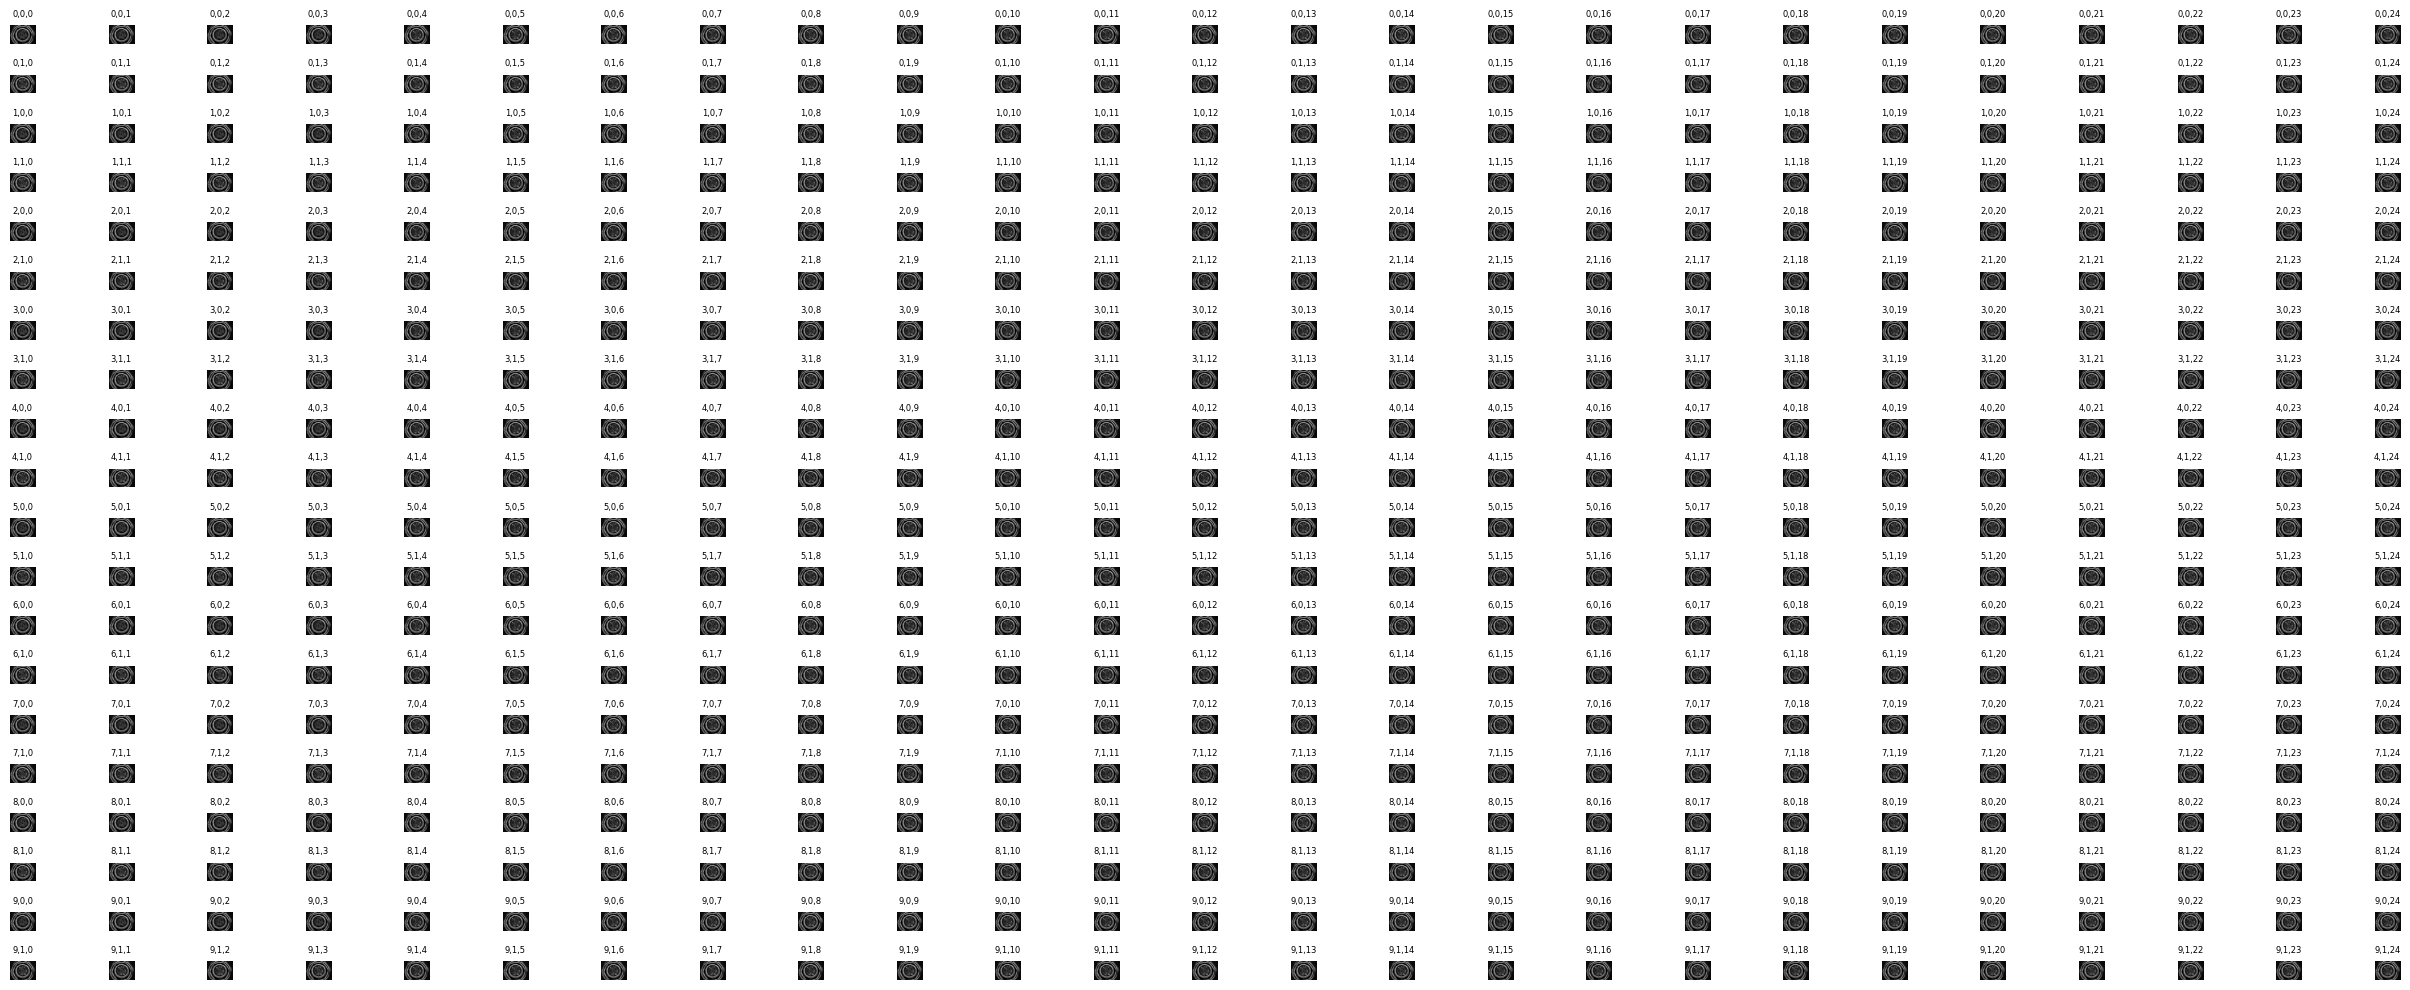

In [24]:
comb=printers[0]
X_c, y_c = get_data(
            dataset, X,
            printer=comb[0],
            filament=comb[1],
            pattern=str(2)
        )
print(X_c.shape)
fig, axes = plt.subplots(len(X_c) * 2, 25, figsize=(25, 10))

for i in range(len(X_c)):
    for j in range(2):
        for k in range(25):
            ax = axes[i * 2 + j, k]
            ax.imshow(X_c[i, j, k], cmap="gray")
            ax.axis("off")
            ax.set_title(f"{i},{j},{k}", fontsize=6)

plt.tight_layout()
plt.show()